# ⚗️ Chemical Engineering: Reaction Kinetics & Reactor Design
**Topics Covered:** CSTR, PFR, Batch Reactor | Arrhenius Equation | Conversion vs Volume

---

In [1]:
# ── Install / import dependencies ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import fsolve
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#cdd6f4',
    'xtick.color':      '#cdd6f4',
    'ytick.color':      '#cdd6f4',
    'text.color':       '#cdd6f4',
    'grid.color':       '#2a2d3e',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
})
COLORS = ['#89b4fa', '#a6e3a1', '#fab387', '#f38ba8', '#cba6f7']
print('✅ Libraries loaded.')

✅ Libraries loaded.


---
## 1 · Arrhenius Equation — Temperature Dependence of Rate Constant

$$k(T) = A \, e^{-E_a / RT}$$

| Symbol | Meaning | Typical units |
|--------|---------|---------------|
| $A$ | Pre-exponential factor | same as $k$ |
| $E_a$ | Activation energy | J/mol |
| $R$ | Gas constant | 8.314 J/mol·K |
| $T$ | Temperature | K |

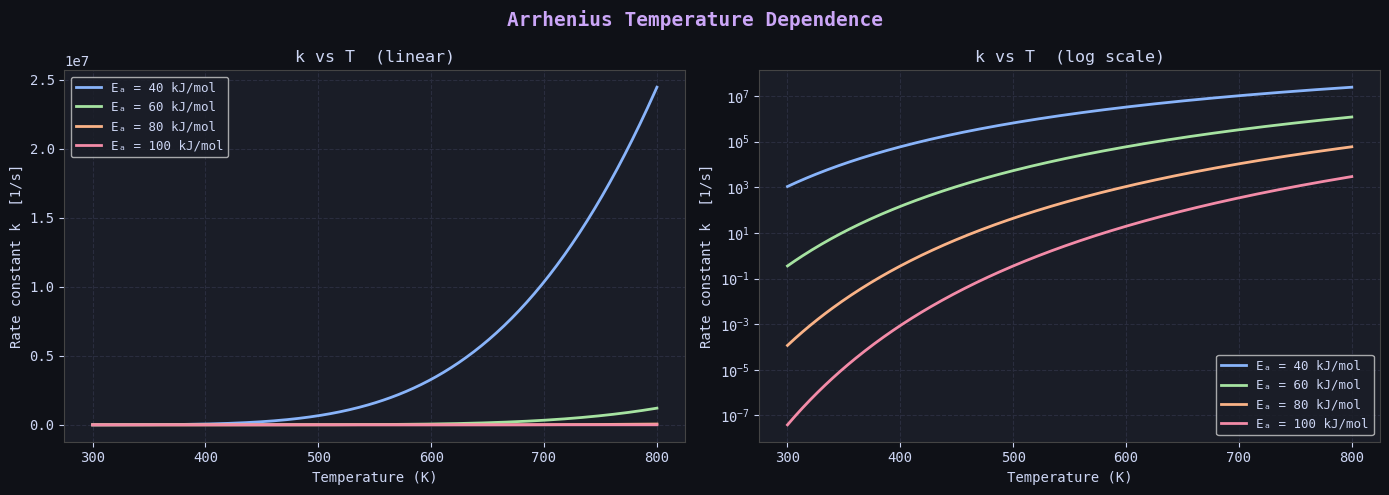

💾 Arrhenius.png


In [2]:
R  = 8.314          # J/(mol·K)
A  = 1e10           # pre-exponential factor  [1/s]
Ea_values = [40e3, 60e3, 80e3, 100e3]   # activation energies [J/mol]

T  = np.linspace(300, 800, 300)         # temperature range [K]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Arrhenius Temperature Dependence', fontsize=14, fontweight='bold', color='#cba6f7')

for i, Ea in enumerate(Ea_values):
    k = A * np.exp(-Ea / (R * T))
    label = f'Eₐ = {Ea/1e3:.0f} kJ/mol'
    axes[0].plot(T, k,           color=COLORS[i], lw=2, label=label)
    axes[1].semilogy(T, k,       color=COLORS[i], lw=2, label=label)

for ax, title in zip(axes, ['k vs T  (linear)', 'k vs T  (log scale)']):
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Rate constant k  [1/s]')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.show()
print('💾 Arrhenius.png')

---
## 2 · Batch Reactor — First-Order Reaction

$$\frac{dC_A}{dt} = -k C_A \quad \Rightarrow \quad C_A(t) = C_{A0}\,e^{-kt}$$

Conversion: $X_A = 1 - C_A/C_{A0}$

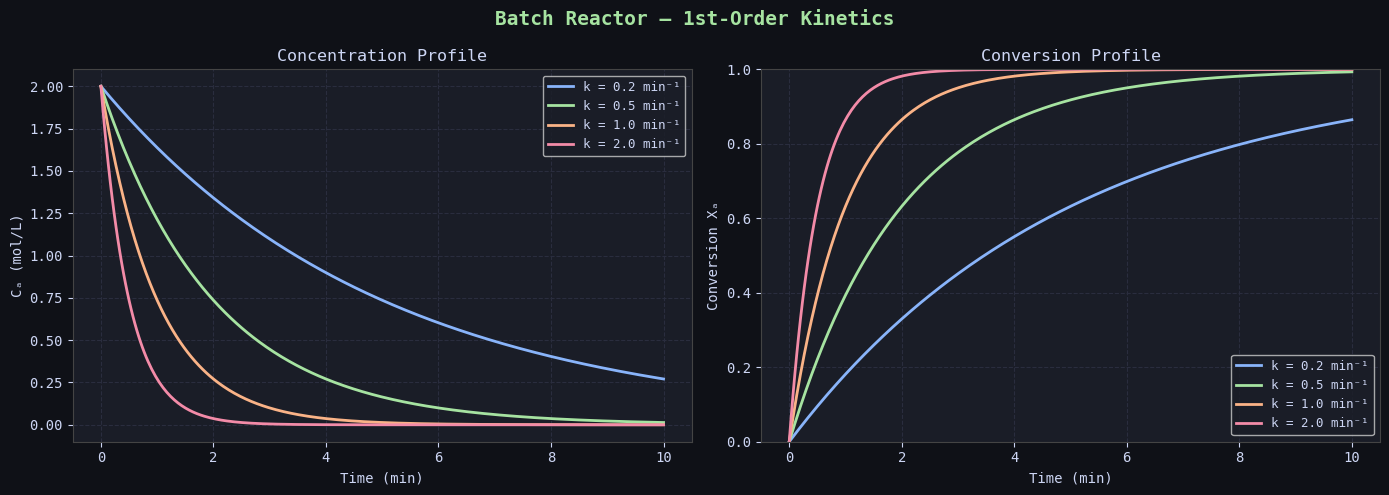

In [3]:
def batch_first_order(C, t, k):
    CA = C[0]
    return [-k * CA]

CA0 = 2.0          # mol/L
t   = np.linspace(0, 10, 300)   # minutes
k_vals = [0.2, 0.5, 1.0, 2.0]  # 1/min

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Batch Reactor — 1st-Order Kinetics', fontsize=14, fontweight='bold', color='#a6e3a1')

for i, k in enumerate(k_vals):
    sol = odeint(batch_first_order, [CA0], t, args=(k,))
    CA  = sol[:, 0]
    XA  = 1 - CA / CA0
    lbl = f'k = {k} min⁻¹'
    axes[0].plot(t, CA, color=COLORS[i], lw=2, label=lbl)
    axes[1].plot(t, XA, color=COLORS[i], lw=2, label=lbl)

axes[0].set(xlabel='Time (min)', ylabel='Cₐ (mol/L)', title='Concentration Profile')
axes[1].set(xlabel='Time (min)', ylabel='Conversion Xₐ', title='Conversion Profile', ylim=(0,1))
for ax in axes:
    ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.show()

---
## 3 · CSTR vs PFR — Volume Comparison

For elementary reaction $A \rightarrow B$ with $-r_A = k C_{A0}(1-X_A)$:

$$V_{CSTR} = \frac{F_{A0}\,X_A}{-r_A(X_A)} \qquad V_{PFR} = F_{A0}\int_0^{X_A}\frac{dX_A}{-r_A}$$

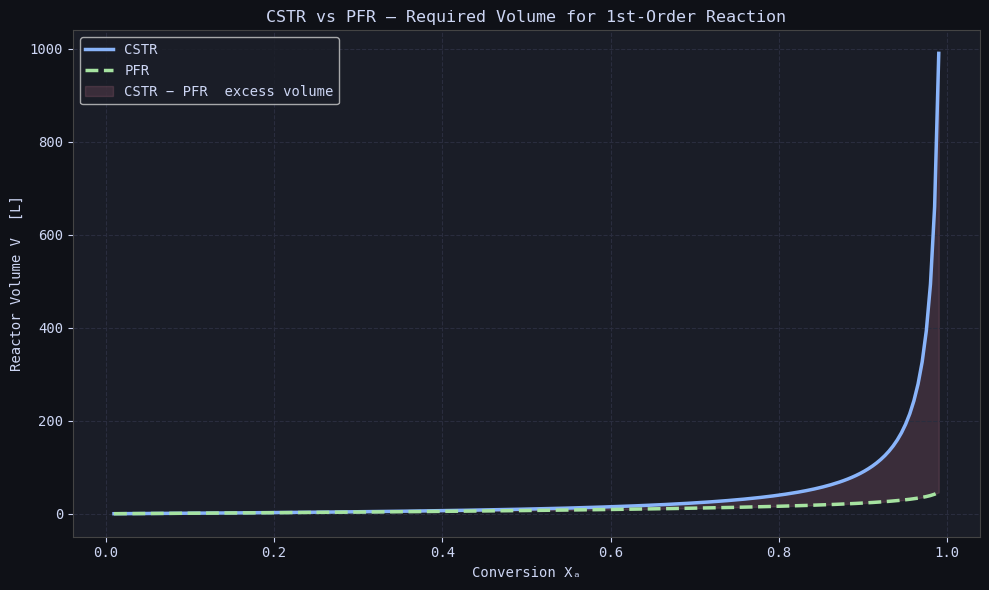


At X = 90%:
  CSTR volume = 90.00 L
  PFR  volume = 23.03 L
  CSTR is 3.91× larger than PFR


In [4]:
from scipy.integrate import quad

k   = 0.5          # 1/min
CA0 = 2.0          # mol/L
FA0 = 10.0         # mol/min  (volumetric flowrate × CA0)
X   = np.linspace(0.01, 0.99, 200)

def minus_rA(x):
    return k * CA0 * (1 - x)

# CSTR: single point evaluation at exit X
V_cstr = [FA0 * x / minus_rA(x) for x in X]

# PFR: integral from 0 → X
V_pfr  = [FA0 * quad(lambda x: 1/minus_rA(x), 0, xi)[0] for xi in X]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(X, V_cstr, color=COLORS[0], lw=2.5, label='CSTR')
ax.plot(X, V_pfr,  color=COLORS[1], lw=2.5, label='PFR', linestyle='--')
ax.fill_between(X, V_pfr, V_cstr, alpha=0.15, color=COLORS[3], label='CSTR − PFR  excess volume')
ax.set(xlabel='Conversion Xₐ', ylabel='Reactor Volume V  [L]',
       title='CSTR vs PFR — Required Volume for 1st-Order Reaction')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

# Print volume at 90% conversion
X_target = 0.90
Vc = FA0 * X_target / minus_rA(X_target)
Vp, _ = quad(lambda x: FA0/minus_rA(x), 0, X_target)
print(f"\nAt X = 90%:")
print(f"  CSTR volume = {Vc:.2f} L")
print(f"  PFR  volume = {Vp:.2f} L")
print(f"  CSTR is {Vc/Vp:.2f}× larger than PFR")

---
## 4 · Non-Isothermal PFR — Energy + Mole Balance (ODE System)

$$\frac{dX}{dV} = \frac{-r_A(X,T)}{F_{A0}} \qquad \frac{dT}{dV} = \frac{-\Delta H_{rx}(-r_A)}{F_{A0}C_{p}}$$

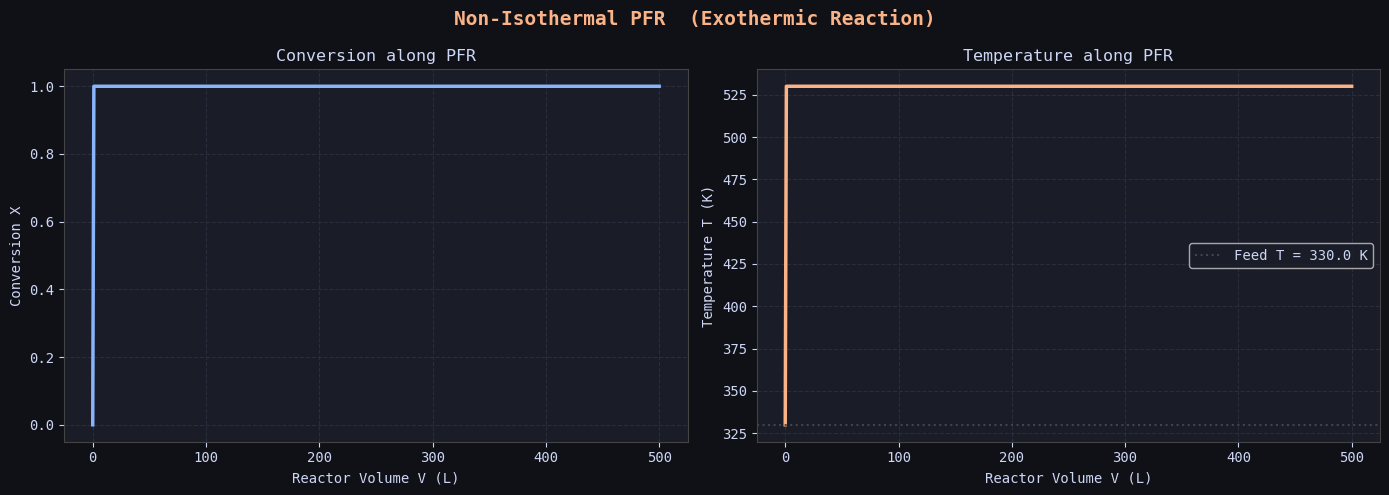


Final conversion:    X = 1.0000
Final temperature:   T = 530.0 K  (ΔT = +200.0 K)


In [5]:
# Parameters
params = dict(
    FA0    = 5.0,      # mol/min
    CA0    = 1.0,      # mol/L
    T0     = 330.0,    # K  (feed temperature)
    Ea     = 65e3,     # J/mol
    A_pre  = 3e12,     # pre-exponential
    dH_rx  = -40e3,    # J/mol  (exothermic)
    Cp     = 200.0,    # J/(mol·K)
    R      = 8.314,
)

def pfr_odes(V, y, p):
    X, T = y
    k    = p['A_pre'] * np.exp(-p['Ea'] / (p['R'] * T))
    rA   = k * p['CA0'] * (1 - X)
    dXdV = rA / p['FA0']
    dTdV = (-p['dH_rx'] * rA) / (p['FA0'] * p['Cp'])
    return [dXdV, dTdV]

V_span = (0, 500)        # L
V_eval = np.linspace(*V_span, 500)
y0     = [0.0, params['T0']]

sol = solve_ivp(pfr_odes, V_span, y0, t_eval=V_eval,
                args=(params,), method='RK45', rtol=1e-8)

X_pfr, T_pfr = sol.y

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Non-Isothermal PFR  (Exothermic Reaction)', fontsize=14, fontweight='bold', color='#fab387')

axes[0].plot(V_eval, X_pfr, color=COLORS[0], lw=2.5)
axes[0].set(xlabel='Reactor Volume V (L)', ylabel='Conversion X', title='Conversion along PFR')

axes[1].plot(V_eval, T_pfr, color=COLORS[2], lw=2.5)
axes[1].axhline(params['T0'], color='#444', linestyle=':', label=f'Feed T = {params["T0"]} K')
axes[1].set(xlabel='Reactor Volume V (L)', ylabel='Temperature T (K)', title='Temperature along PFR')
axes[1].legend()

for ax in axes: ax.grid(True)
plt.tight_layout()
plt.show()

print(f"\nFinal conversion:    X = {X_pfr[-1]:.4f}")
print(f"Final temperature:   T = {T_pfr[-1]:.1f} K  (ΔT = +{T_pfr[-1]-params['T0']:.1f} K)")

---
## 5 · Selectivity in Parallel Reactions

Reactions: $A \xrightarrow{k_1} B$ (desired)  and  $A \xrightarrow{k_2} C$ (undesired)

Instantaneous selectivity: $S_{B/C} = r_B / r_C = k_1/k_2$

In [ ]:
def parallel_batch(y, t, k1, k2):
    CA, CB, CC = y
    r1 = k1 * CA
    r2 = k2 * CA
    return [-r1 - r2, r1, r2]

scenarios = [
    {'k1': 0.8, 'k2': 0.2, 'label': 'High selectivity  k₁/k₂ = 4'},
    {'k1': 0.5, 'k2': 0.5, 'label': 'Equal rates       k₁/k₂ = 1'},
    {'k1': 0.2, 'k2': 0.8, 'label': 'Low selectivity   k₁/k₂ = 0.25'},
]

t   = np.linspace(0, 8, 400)
y0  = [2.0, 0.0, 0.0]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Parallel Reactions — Effect of Selectivity', fontsize=13, fontweight='bold', color='#cba6f7')

for ax, sc in zip(axes, scenarios):
    sol = odeint(parallel_batch, y0, t, args=(sc['k1'], sc['k2']))
    ax.plot(t, sol[:,0], color=COLORS[0], lw=2, label='A (reactant)')
    ax.plot(t, sol[:,1], color=COLORS[1], lw=2, label='B (desired)')
    ax.plot(t, sol[:,2], color=COLORS[3], lw=2, label='C (undesired)')
    ax.set_title(sc['label'], fontsize=9)
    ax.set(xlabel='Time (min)', ylabel='Concentration (mol/L)')
    ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.show()

---
## ✅ Summary

| Concept | Key Equation | Method Used |
|---------|-------------|-------------|
| Arrhenius | $k=Ae^{-Ea/RT}$ | NumPy vectorised |
| Batch reactor | $dC_A/dt = -kC_A$ | `scipy.odeint` |
| CSTR vs PFR | Levenspiel plot | `scipy.integrate.quad` |
| Non-isothermal PFR | Coupled ODE system | `scipy.solve_ivp` |
| Parallel reactions | Selectivity analysis | `scipy.odeint` |

> **Next steps:** Add heat exchangers, recycle loops, or import real plant data from CSV.